![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# CSCK506 Deep Learning: END-MODULE ASSIGNMENT

Pneumonia is an inflammatory condition of the lungs and remains a common and potentially serious disease worldwide. Early and accurate diagnosis is essential for effective treatment, yet traditional methods—such as manual interpretation of chest X-ray images—can be time-consuming and subject to variability among clinicians.

This project explores automated deep learning approaches to detect pneumonia from medical images, with the goal of assisting and improving diagnostic processes.

### Objectives
- Develop models capable of accurately classifying chest X-ray images as NORMAL or PNEUMONIA
- Compare baseline and advanced deep learning approaches
- Evaluate the impact of preprocessing, augmentation, and transfer learning
- Optimize model performance using appropriate metrics (Accuracy, AUC, Precision, Recall, F1-score)


### Project Structure

The project is organized into three main notebooks, each focusing on a key stage of the machine learning pipeline:

1. Exploratory Data Analysis (EDA)
- Understand dataset structure and distribution
- Visualize class imbalance and sample images
- Identify potential challenges (noise, variability, imbalance)

2. Preprocessing & CNN Models

- Data preprocessing and pipeline setup
- Model experimentation with three baselines:

        i. Baseline CNN (no augmentation)
        ii. Baseline CNN with data augmentation
        iii. Tuned CNN (optimized hyperparameters)

The goal is to establish strong reference models and understand the impact of basic improvements.

3. Transfer Learning & Model Comparison
- Use pretrained models VGG16 for feature extraction and fine-tuning
- Improve performance through transfer learning
- Compare all models using standardized evaluation metrics
- Analyze trade-offs between performance and complexity

### Expected Outcomes

By the end of this project, we aim to:

- Identify the most effective modeling approach for pneumonia detection
- Quantify the benefits of augmentation and transfer learning
- Provide a clear comparison of all models

Overall, the goal is to develop a reliable and interpretable diagnostic support tool.

**This notebook is dedicated to Preprocessing and CNN Models.**

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 02 - Pneumonia Detection: CNN Models

Train and evaluate three baseline CNN architectures on the chest X-ray dataset:

| Model | Description |
|-------|-------------|
| **A** | Baseline CNN without data augmentation |
| **B** | Baseline CNN with in-graph data augmentation |
| **C** | Baseline CNN with Keras Tuner hyperparameter optimisation |

All models use sklearn-balanced class weighting via `compute_class_weights()`, decision-threshold tuning on PNEUMONIA F1, and evaluation on a held-out test set.

**Sections**
1. Environment Setup
2. Configuration
3. Data Loading & Preprocessing
4. Model A — Baseline CNN (No Augmentation)
5. Model B — Baseline CNN (With Augmentation)
6. Overfitting Countermeasures
7. Model C — Baseline CNN (Tuned Hyperparameters)
8. Conclusion — CNN Model Comparison

### 1. Environment Setup

Import all dependencies, install optional packages, and set random seeds.

In [ ]:
import os
import sys
import json
import random
import pandas as pd
import pathlib
import importlib.util
import subprocess
import importlib
from datetime import datetime

# Local environments can miss optional tuning deps required by keras-tuner.
for pkg_name in ["tensorboard", "keras-tuner"]:
    if importlib.util.find_spec(pkg_name.replace("-", "_")) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg_name], check=False)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
import keras_tuner as kt
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.19.0
Keras: 3.13.2


### 2. Configuration

Dataset paths, image size, batch size, checkpoint locations, and runtime flags.

In [ ]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [ ]:
# Configuration
if USE_KAGGLE:

    KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
    KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"

    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")

    try:
        from helpers import data_utils, model_utils, training_utils, visualization
    except ModuleNotFoundError:
        for p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
            if os.path.isdir(p) and p not in sys.path:
                sys.path.append(p)
        from helpers import data_utils, model_utils, training_utils, visualization

elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")

    # Point to the folder containing the 'helpers' folder
    if "/content/drive/MyDrive/Colab Notebooks" not in sys.path:
        sys.path.append("/content/drive/MyDrive/Colab Notebooks")

    from helpers import data_utils, model_utils, training_utils, visualization

    importlib.reload(data_utils)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(visualization)

else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_WITHOUT_AUG_CHECKPOINT_PATH = SAVE_DIR / "baseline_without_aug_best_checkpoint.keras"
BASELINE_CHECKPOINT_PATH = SAVE_DIR / "baseline_best_checkpoint.keras"
TUNED_CHECKPOINT_PATH = SAVE_DIR / "baseline_tuned_best_checkpoint.keras"

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment: {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")

Mounted at /content/drive
Environment: Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/
Model artifacts will be stored in: /content/drive/MyDrive/saved_models


### 3. Data Loading & Preprocessing

Build stratified train/validation splits from the training pool, construct balanced `tf.data` pipelines, and define the augmentation stack.

In [ ]:
# Collect all file paths and labels from train plus optional original val directory
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    VAL_DIR,
)

print(f"Source pool size (train + optional original val): {len(all_train_paths)} images")

Source pool size (train + optional original val): 5232 images


In [ ]:
# Build train/val/test datasets from helper
train_ds, val_ds, test_ds, dataset_meta = data_utils.build_train_val_test_datasets(
    train_paths=all_train_paths,
    train_labels=all_train_labels,
    test_paths=test_paths,
    test_labels=test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    preprocess_fn=None,
    autotune=AUTOTUNE,
)

train_paths = dataset_meta["train_paths"]
train_labels_raw = dataset_meta["train_labels_raw"]
val_paths = dataset_meta["val_paths"]
val_labels_arr = dataset_meta["val_labels"]
normal_count = dataset_meta["normal_count"]
pneumonia_count = dataset_meta["pneumonia_count"]
steps_per_epoch = dataset_meta["steps_per_epoch"]

print(f"Stratified split (before balancing): {len(train_paths)} train, {len(val_paths)} val")
print(f"  Train before -> NORMAL={normal_count}, PNEUMONIA={pneumonia_count}")
print(f"  Val          -> NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}")
print(f"  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch")
print(f"  Steps per epoch: {steps_per_epoch}")

class_names = ["NORMAL", "PNEUMONIA"]
print("Class names:", class_names)
print("Note: dataset/val folder excluded; validation split is stratified from dataset/train.")

Stratified split (before balancing): 4708 train, 524 val
  Train before -> NORMAL=1214, PNEUMONIA=3494
  Val          -> NORMAL=135, PNEUMONIA=389
  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch
  Steps per epoch: 148
Class names: ['NORMAL', 'PNEUMONIA']
Note: dataset/val folder excluded; validation split is stratified from dataset/train.


In [ ]:
# Augmentation layers
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

In [ ]:
# Performance optimization for tf.data pipelines
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Datasets are ready.")

Datasets are ready.


#### 3.1 Balanced Sampling & Augmentation Verification

Confirm that the balanced sampling strategy and augmentation pipeline produce the expected output.

Class distribution check
  Train before balancing: NORMAL=1214, PNEUMONIA=3494
  Train after balancing : NORMAL~2368, PNEUMONIA~2368 (sampled)
  Validation            : NORMAL=135, PNEUMONIA=389


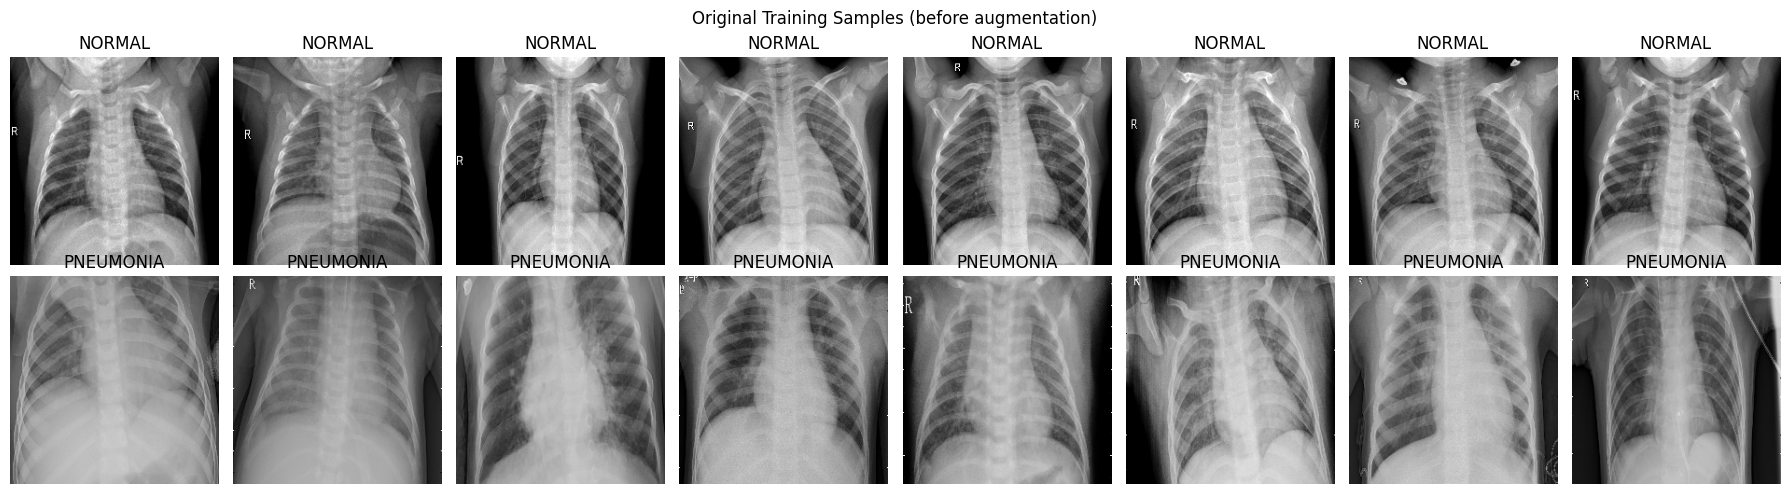

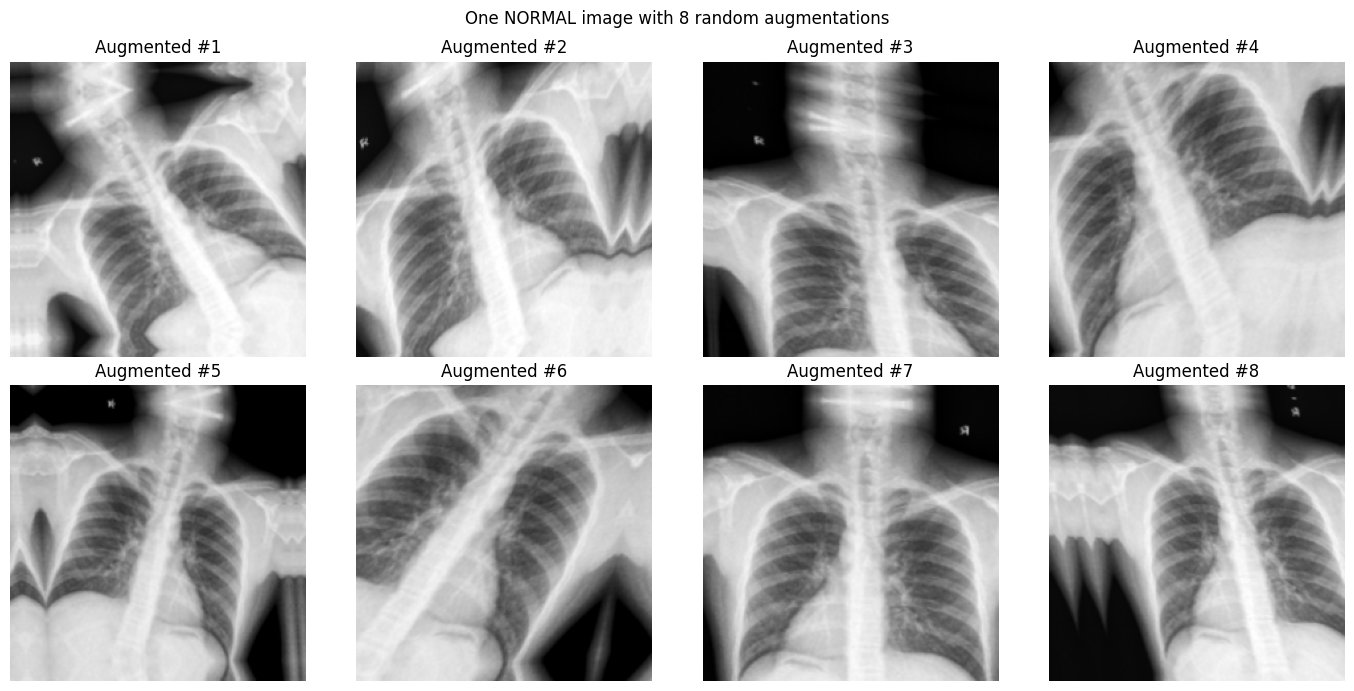

In [ ]:
normal_paths = train_paths[train_labels_raw == 0]
pneumonia_paths = train_paths[train_labels_raw == 1]

# For diagnostics only: effective per-epoch class counts under 1:1 sampled training.
balanced_epoch_count = steps_per_epoch * BATCH_SIZE // 2

print("Class distribution check")
print(f"  Train before balancing: NORMAL={(train_labels_raw==0).sum()}, PNEUMONIA={(train_labels_raw==1).sum()}")
print(f"  Train after balancing : NORMAL~{balanced_epoch_count}, PNEUMONIA~{balanced_epoch_count} (sampled)")
print(f"  Validation            : NORMAL={(val_labels_arr==0).sum()}, PNEUMONIA={(val_labels_arr==1).sum()}")

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
normal_sample_paths = rng.choice(normal_paths, size=min(8, len(normal_paths)), replace=False)
pneumonia_sample_paths = rng.choice(pneumonia_paths, size=min(8, len(pneumonia_paths)), replace=False)

for i in range(8):
    if i < len(normal_sample_paths):
        img = keras.utils.load_img(normal_sample_paths[i], target_size=IMG_SIZE)
        axes[0, i].imshow(img)
        axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

    if i < len(pneumonia_sample_paths):
        img = keras.utils.load_img(pneumonia_sample_paths[i], target_size=IMG_SIZE)
        axes[1, i].imshow(img)
        axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.suptitle("Original Training Samples (before augmentation)")
plt.tight_layout()
plt.show()

sample_normal = keras.utils.load_img(normal_paths[0], target_size=IMG_SIZE)
sample_tensor = tf.expand_dims(tf.cast(keras.utils.img_to_array(sample_normal), tf.float32), axis=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, ax in enumerate(axes.flat):
    aug_img = data_augmentation(sample_tensor, training=True)[0]
    aug_img = tf.clip_by_value(aug_img / 255.0, 0.0, 1.0)
    ax.imshow(aug_img)
    ax.set_title(f"Augmented #{idx+1}")
    ax.axis("off")

plt.suptitle("One NORMAL image with 8 random augmentations")
plt.tight_layout()
plt.show()

#### 3.2 Helper Utilities

Bind the shared model-saver closure to this notebook’s save directory.

In [ ]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)

<hr style="height:6px;background-color:blue;border:none;">

### 4. Model A — Baseline CNN (No Augmentation)

A regularised CNN with batch normalisation, progressive dropout, and L2 regularisation — trained **without** any data augmentation to serve as a lower-bound reference.

In [ ]:
# Baseline CNN model (no transfer-learning backbone)
model_without_aug = model_utils.build_baseline_cnn(
    img_size=IMG_SIZE,
    augmentation_layer=None,
    learning_rate=1e-3,
    l2_reg=1e-4,
    name="baseline_pneumonia_cnn",
)
model_without_aug.summary()

Model: "baseline_pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,02

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

#### 4.1 Training

In [ ]:
my_callbacks_no_aug = training_utils.get_training_callbacks(
    checkpoint_path=BASELINE_WITHOUT_AUG_CHECKPOINT_PATH,
    patience=3,
    monitor="val_accuracy",
)

class_weight = data_utils.compute_class_weights(train_labels_raw, strategy="balanced")
print("Class weights:", class_weight)


if BASELINE_WITHOUT_AUG_CHECKPOINT_PATH.exists():
    Training = False
    print(f"Loading existing baseline checkpoint: {BASELINE_WITHOUT_AUG_CHECKPOINT_PATH}")
    best_model_without_aug = training_utils.load_model_compat(BASELINE_WITHOUT_AUG_CHECKPOINT_PATH)
    history_model_without_aug = None
else:
    Training = True
    history_model_without_aug = model_without_aug.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=my_callbacks_no_aug,
        class_weight=class_weight,
    )
    print(f"Best baseline checkpoint saved to: {BASELINE_WITHOUT_AUG_CHECKPOINT_PATH}")

Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 138s 754ms/step - accuracy: 0.8740 - auc: 0.9468 - loss: 0.3308 - pr_auc: 0.9803 - val_accuracy: 0.7424 - val_auc: 0.4589 - val_loss: 1.7042 - val_pr_auc: 0.7263 - learning_rate: 0.0010
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9212 - auc: 0.9780 - loss: 0.2347 - pr_auc: 0.9920 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 2.0570 - val_pr_auc: 0.7424 - learning_rate: 0.0010
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9586 - auc: 0.9921 - loss: 0.1668 - pr_auc: 0.9971 - val_accuracy: 0.7424 - val_auc: 0.5617 - val_loss: 1.6564 - val_pr_auc: 0.7668 - learning_rate: 3.0000e-04
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9703 - auc: 0.9960 - loss: 0.1397 - pr_auc: 0.9986 - val_accuracy: 0.8931 - val_auc: 0.9963 - val_loss: 0.2779 - val_pr_auc: 0.9988 - learning_rate: 9.0000e-05
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━

#### 4.2 Evaluation

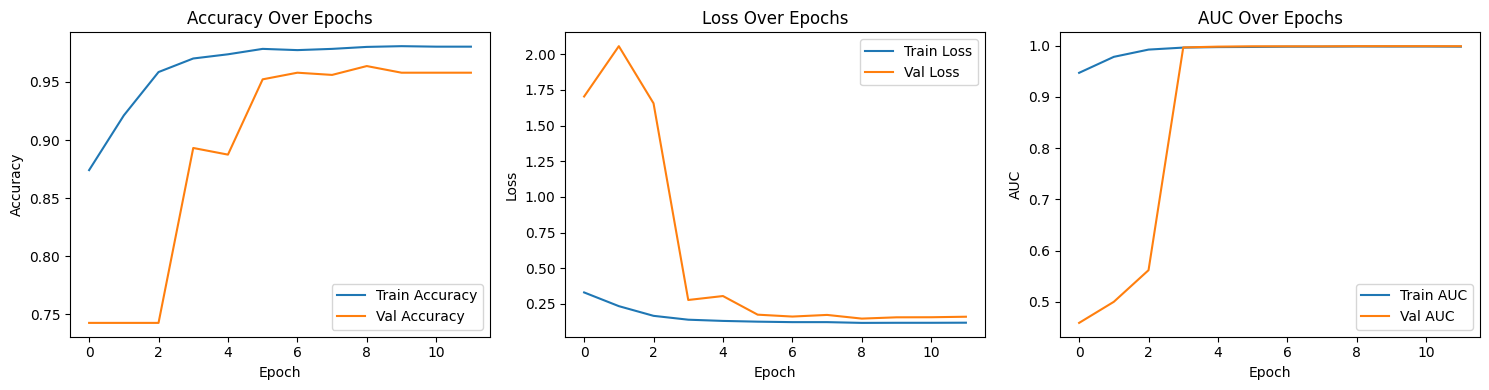

In [ ]:
# Plot training curves (loss, accuracy, and AUC)
if history_model_without_aug is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    visualization.plot_training_history(history_model_without_aug)

In [ ]:
MODEL_TO_LOAD = BASELINE_WITHOUT_AUG_CHECKPOINT_PATH

if not MODEL_TO_LOAD.exists():
    raise FileNotFoundError(
        f"Model file not found at {MODEL_TO_LOAD}. Run training first."
    )
if Training:
    best_model_without_aug = training_utils.load_model_compat(MODEL_TO_LOAD)

In [ ]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [ ]:
# Threshold tuning on validation split (PNEUMONIA F1)
best_threshold_no_aug, best_f1_no_aug, _, _ = training_utils.tune_threshold(
    best_model_without_aug, val_ds
)
print(f"Best threshold from validation split (macro F1): {best_threshold_no_aug:.2f}")

Best threshold from validation split (macro F1): 0.79


Test ROC-AUC: 0.8967


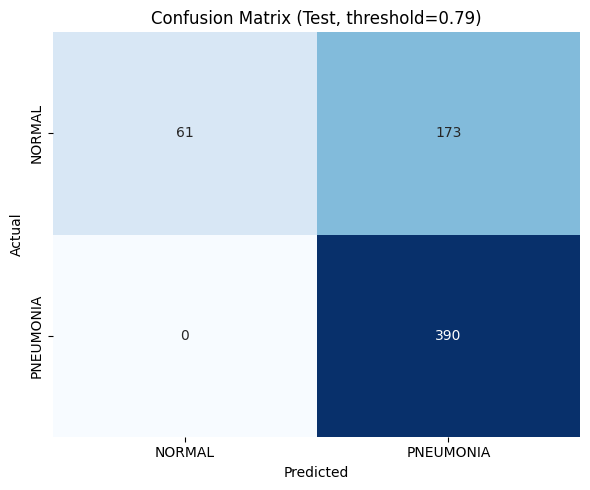

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       1.00      0.26      0.41       234
   PNEUMONIA       0.69      1.00      0.82       390

    accuracy                           0.72       624
   macro avg       0.85      0.63      0.62       624
weighted avg       0.81      0.72      0.67       624



In [ ]:
# Evaluate on test set
metrics_no_aug, report_no_aug, y_true, y_prob, y_pred = training_utils.evaluate_model(
    best_model_without_aug, test_ds, best_threshold_no_aug
)
test_roc_auc = metrics_no_aug["auc"]
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

visualization.plot_confusion_and_report(y_true, y_pred, best_threshold_no_aug)

**Interpretation**

The baseline CNN without augmentation established the initial benchmark, achieving an overall accuracy of 0.72. Although the model achieved perfect recall for pneumonia (1.00), it exhibited low precision (0.69), indicating a strong tendency to over-predict pneumonia cases. Specifically, while the model successfully identified all 390 pneumonia cases (0 false negatives), it misclassified the vast majority of healthy patients, generating 173 false positives. 

Consequently, the 0.72 accuracy metric is heavily skewed by the model's bias toward the positive class; it acts as a perfect safety net but remains operationally inefficient due to the high volume of false alarms.

_Bottom Line_: The baseline model defaults to predicting "pneumonia" to avoid making a fatal error. It achieves a 72% accuracy and a 100% safety net, but it sacrifices the healthy patients to do so, creating a "boy who cried wolf" scenario for hospital staff.

#### 4.3 Save Model Artifacts

In [ ]:
# Persist baseline model artifacts and metadata
if Training:

    no_aug_hyperparams = {
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "optimizer": "Adam",
        "learning_rate": 1e-4,
        "augmentation": False,
        "class_weight": class_weight,
        "steps_per_epoch": steps_per_epoch,
    }

    if "history_model_without_aug" not in globals():
        history_model_without_aug = None

    save_model_with_meta(best_model_without_aug, "baseline_without_aug_cnn", metrics_no_aug, history_model_without_aug, no_aug_hyperparams, best_threshold_no_aug)

Saved model to: /content/drive/MyDrive/saved_models/baseline_without_aug_cnn.keras
Saved metadata to: /content/drive/MyDrive/saved_models/baseline_without_aug_cnn_meta.json


### 4.4 Probability Distribution Diagnostic

Inspect how predicted probabilities separate NORMAL vs PNEUMONIA on the test set.

NORMAL samples: 234 | PNEUMONIA samples: 390


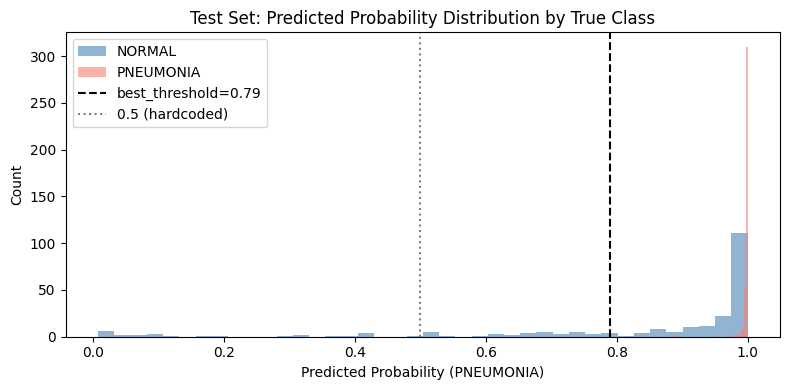

In [ ]:
# Diagnostic: probability distribution by true class on test set
visualization.plot_probability_distribution(y_true, y_prob, best_threshold_no_aug)

#### 4.5 Sample Predictions

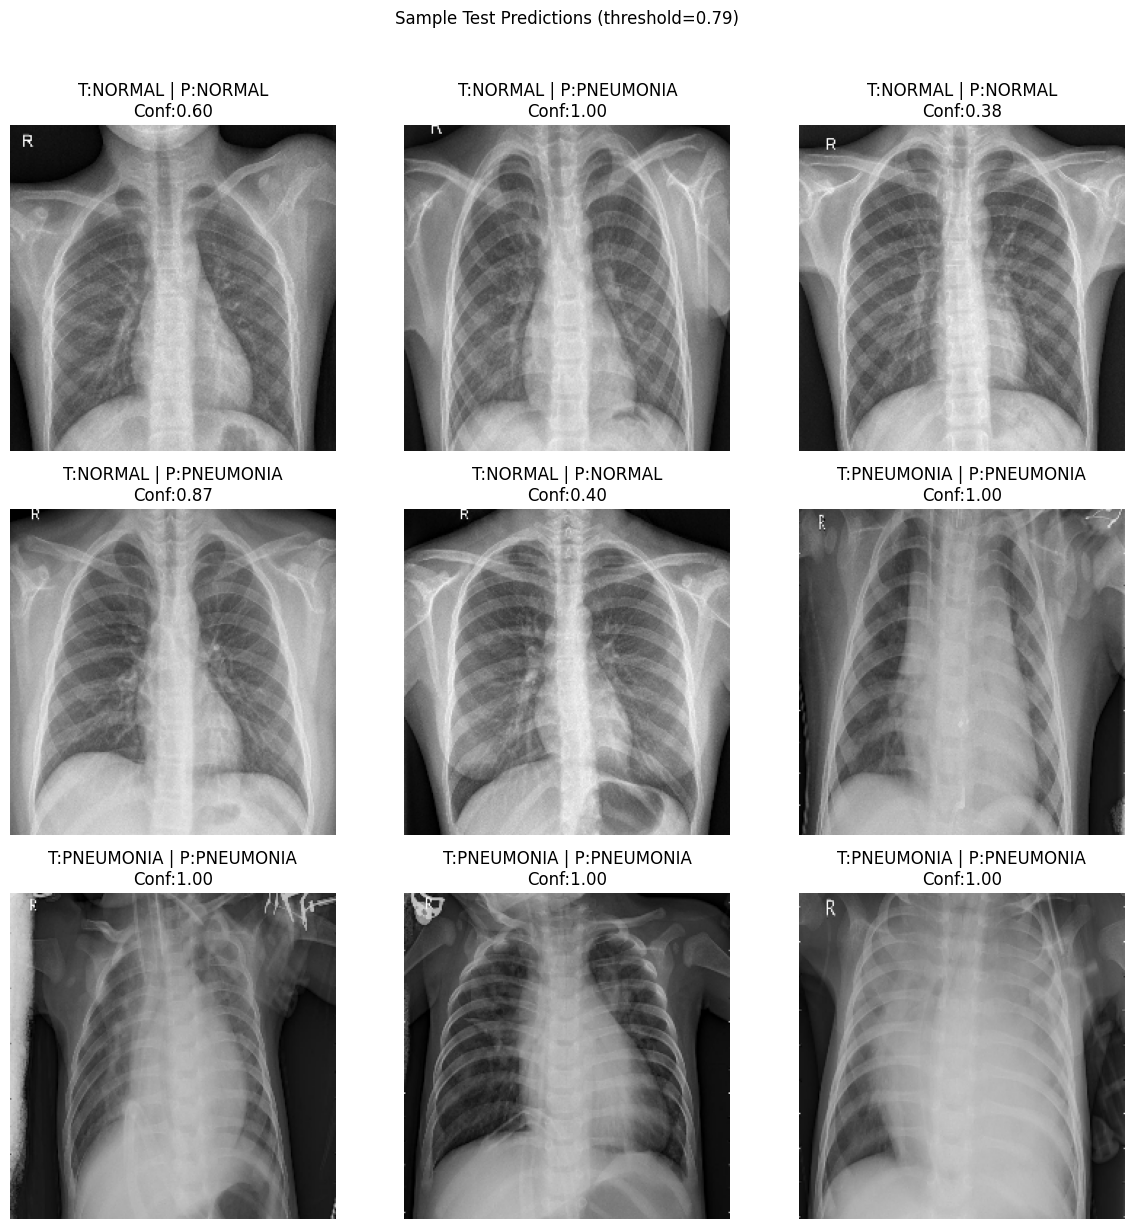

In [ ]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
visualization.plot_sample_test_predictions(test_ds, best_model_without_aug, best_threshold_no_aug)

<hr style="height:6px;background-color:blue;border:none;">

### 5. Model B — Baseline CNN (With Augmentation)

The same CNN architecture as Model A, but with an in-graph augmentation layer (`RandomFlip`, `RandomRotation`, `RandomTranslation`, `RandomZoom`, `RandomShear`, `RandomBrightness`).  The augmentation layer is part of the model and is only active during training.

In [ ]:
# Baseline CNN model (no transfer-learning backbone)

model_with_aug = model_utils.build_baseline_cnn(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    learning_rate=1e-3,
    l2_reg=1e-4,
    name="pneumonia_cnn",
)
model_with_aug.summary()

Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

#### 5.1 Dataset Summary

In [ ]:
print("Balanced training split distribution (sampled):")
print(f"  NORMAL~{steps_per_epoch * BATCH_SIZE // 2}, PNEUMONIA~{steps_per_epoch * BATCH_SIZE // 2}, TOTAL~{steps_per_epoch * BATCH_SIZE}")
print("Validation split distribution:")
print(f"  NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}, TOTAL={len(val_labels_arr)}")

print("Model is already compiled by model_utils.build_baseline_cnn with PR-AUC and gradient clipping.")

Balanced training split distribution (sampled):
  NORMAL~2368, PNEUMONIA~2368, TOTAL~4736
Validation split distribution:
  NORMAL=135, PNEUMONIA=389, TOTAL=524
Model is already compiled by model_utils.build_baseline_cnn with PR-AUC and gradient clipping.


#### 5.2 Training

In [ ]:
# Train with callbacks (early stopping, LR schedule, checkpointing) and resume from checkpoint when available.

my_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=BASELINE_CHECKPOINT_PATH,
    patience=3,
    monitor="val_accuracy",
)

class_weight = data_utils.compute_class_weights(train_labels_raw, strategy="balanced")
print("Class weights:", class_weight)

if BASELINE_CHECKPOINT_PATH.exists():
    Training = False
    print(f"Loading existing baseline checkpoint: {BASELINE_CHECKPOINT_PATH}")
    best_model_with_aug = training_utils.load_model_compat(BASELINE_CHECKPOINT_PATH)
    history_model_with_aug = None
else:
    Training = True
    history_model_with_aug = model_with_aug.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=my_callbacks,
        class_weight=class_weight,
    )
    print(f"Best baseline checkpoint saved to: {BASELINE_CHECKPOINT_PATH}")

Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.7587 - auc: 0.8559 - loss: 0.5128 - pr_auc: 0.9454 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 6.7284 - val_pr_auc: 0.7424 - learning_rate: 0.0100
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8224 - auc: 0.9038 - loss: 0.4272 - pr_auc: 0.9619 - val_accuracy: 0.7424 - val_auc: 0.5074 - val_loss: 2.9796 - val_pr_auc: 0.7452 - learning_rate: 0.0100
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8339 - auc: 0.9136 - loss: 0.4043 - pr_auc: 0.9683 - val_accuracy: 0.7500 - val_auc: 0.7326 - val_loss: 1.3378 - val_pr_auc: 0.8499 - learning_rate: 0.0100
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8503 - auc: 0.9260 - loss: 0.3709 - pr_auc: 0.9726 - val_accuracy: 0.7691 - val_auc: 0.8409 - val_loss: 0.7525 - val_pr_auc: 0.9280 - learning_rate: 0.0100
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 61

#### 5.3 Evaluation

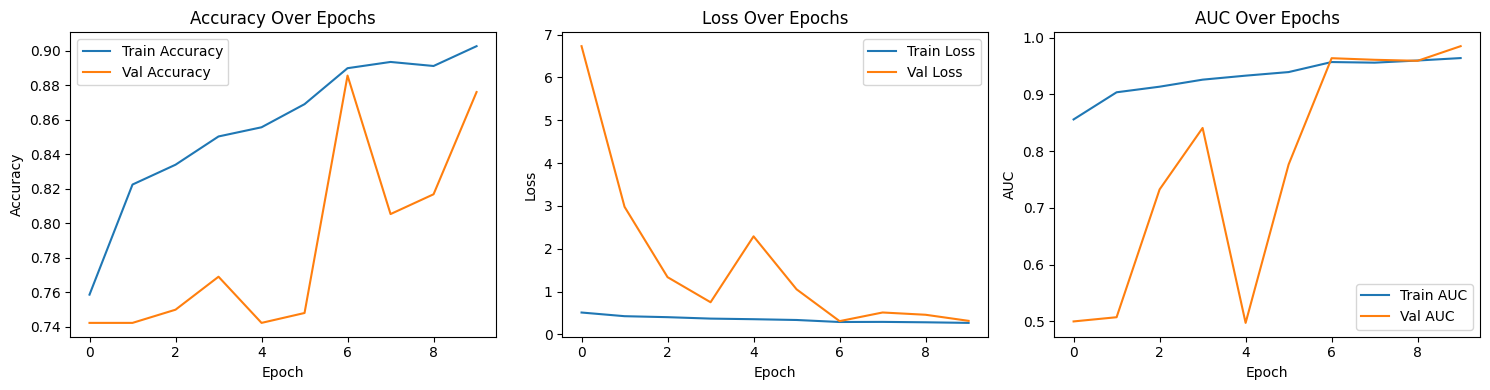

In [ ]:
# Plot training curves (loss, accuracy, and AUC)
if history_model_with_aug is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    visualization.plot_training_history(history_model_with_aug)

In [ ]:
# Baseline checkpoint loading stage
print("Loading baseline checkpoint for threshold tuning and test evaluation...")

Loading baseline checkpoint for threshold tuning and test evaluation...


In [ ]:
MODEL_TO_LOAD = BASELINE_CHECKPOINT_PATH
if not MODEL_TO_LOAD.exists():
    raise FileNotFoundError(
        f"Model file not found at {MODEL_TO_LOAD}. Run training first."
    )
if Training:
    best_model_with_aug = training_utils.load_model_compat(MODEL_TO_LOAD)

print(f"Loaded model from: {MODEL_TO_LOAD}")
print(f"Model input shape: {best_model_with_aug.input_shape}")
print(f"Model output shape: {best_model_with_aug.output_shape}")

Loaded model from: /content/drive/MyDrive/saved_models/baseline_best_checkpoint.keras
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1)


In [ ]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [ ]:
# Threshold tuning on validation split (PNEUMONIA F1)
best_threshold, best_f1_val, _, _ = training_utils.tune_threshold(best_model_with_aug, val_ds)
print(f"Best threshold from validation split (macro F1): {best_threshold:.2f}")

Best threshold from validation split (macro F1): 0.33


Test ROC-AUC: 0.8930


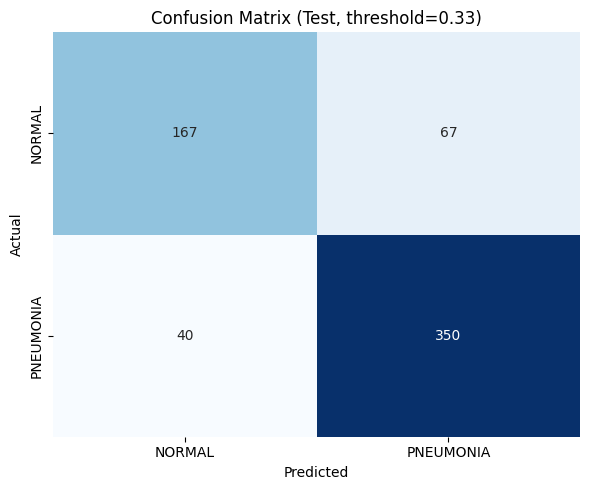

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.81      0.71      0.76       234
   PNEUMONIA       0.84      0.90      0.87       390

    accuracy                           0.83       624
   macro avg       0.82      0.81      0.81       624
weighted avg       0.83      0.83      0.83       624



In [ ]:
# Evaluate on test set
baseline_metrics_dict, baseline_report, y_true, y_prob, y_pred = training_utils.evaluate_model(
    best_model_with_aug, test_ds, best_threshold
)
test_roc_auc = baseline_metrics_dict["auc"]
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

visualization.plot_confusion_and_report(y_true, y_pred, best_threshold)

**Interpretation**

The baseline CNN with data augmentation showed notable gains over the original benchmark, reaching an overall accuracy of 0.83 (up from 0.72). While the model’s recall for pneumonia declined from 1.00 to 0.90, its precision improved substantially to 0.84 (from 0.69), indicating a successful reduction in the over-prediction of pneumonia cases. In detail, the model missed 40 pneumonia cases, introducing false negatives, but correctly identified a far larger proportion of healthy patients, lowering false positives from 173 to 67.

The 0.83 accuracy reflects a truly balanced performance across both classes rather than a skew toward positive cases. This makes the model much more operationally efficient by reducing false alarms, though it sacrifices the perfect safety net provided by the unaugmented model.

_Bottom Line_: The augmented CNN effectively addresses the pronounced “false alarm” bias of the original baseline. It achieves a more reliable 83% accuracy and greatly reduces operational inefficiency by correctly identifying healthy patients. However, the trade-off is a reduced safety net, as it now misses 10% of pneumonia cases (40 patients), requiring clinical oversight.

#### 5.4 Save Model Artifacts

In [ ]:
# Persist baseline model artifacts and metadata
if Training:

    baseline_hyperparams = {
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "optimizer": "Adam",
        "learning_rate": 1e-4,
        "augmentation": True,
        "class_weight": class_weight,
        "steps_per_epoch": steps_per_epoch,
    }

    if "history_model_with_aug" not in globals():
        history_model_with_aug = None

    save_model_with_meta(
        best_model_with_aug, "baseline_cnn", baseline_metrics_dict, history_model_with_aug,
        baseline_hyperparams, best_threshold
    )

    print("\nSummary:")
    print("- Validation now uses a large split from dataset/train instead of the tiny val folder.")
    print("- Training uses sklearn balanced class_weight to handle class imbalance.")
    print("- Decision threshold tuned on validation split before final test evaluation.")

#### 5.5 Probability Distribution Diagnostic

Inspect how predicted probabilities separate NORMAL vs PNEUMONIA on the test set.

NORMAL samples: 234 | PNEUMONIA samples: 390


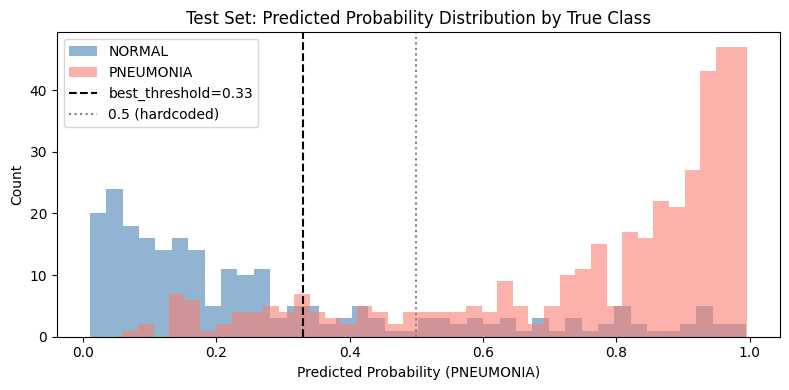

In [ ]:
# Diagnostic: probability distribution by true class on test set
visualization.plot_probability_distribution(y_true, y_prob, best_threshold)

#### 5.6 Sample Predictions

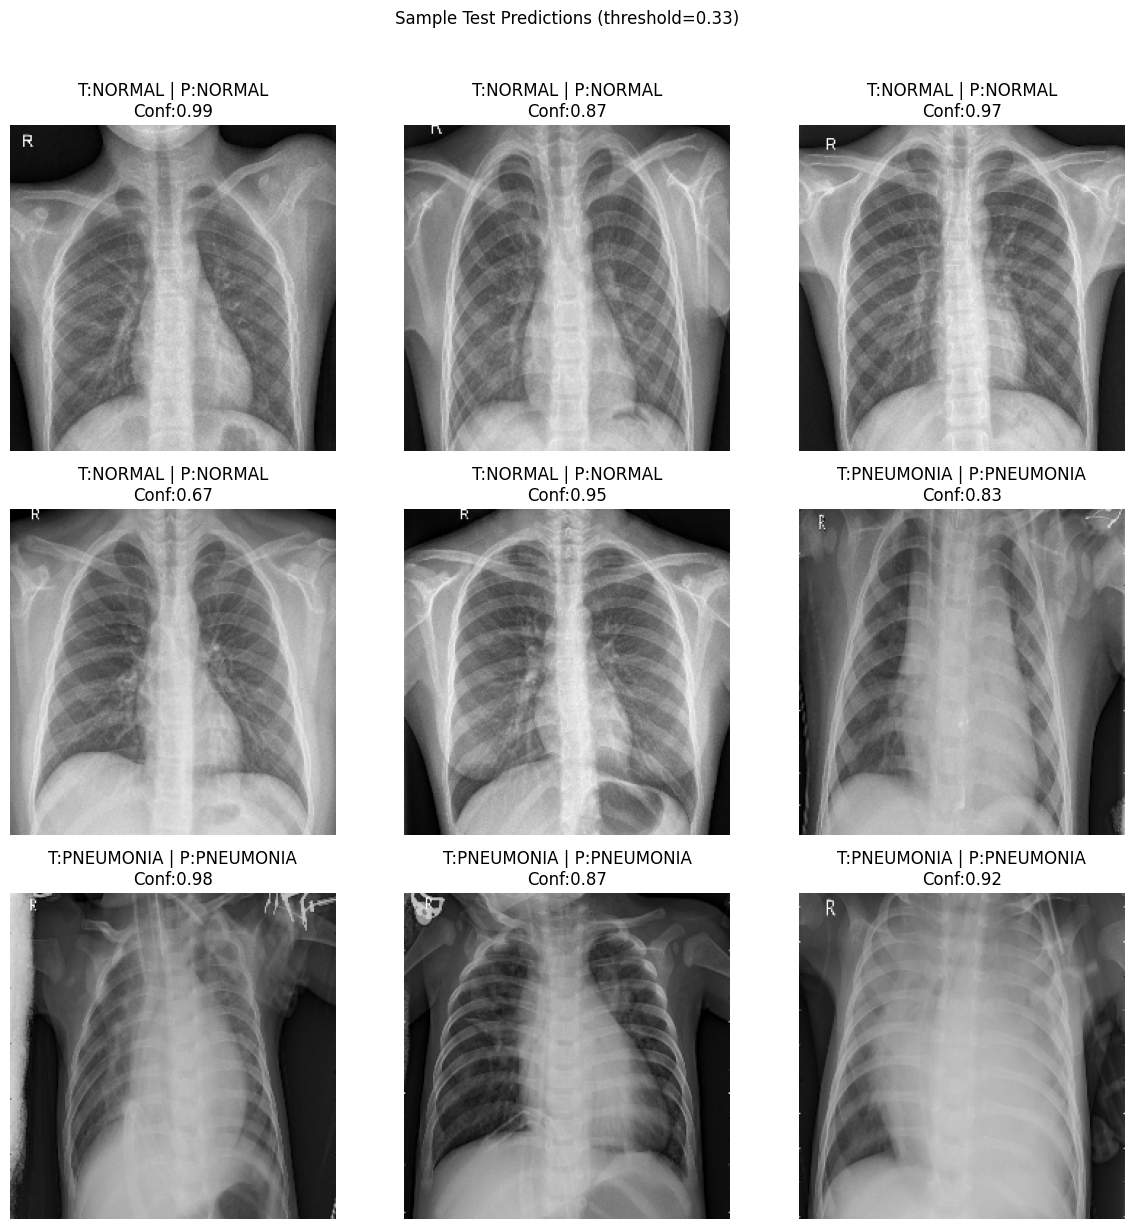

In [ ]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
visualization.plot_sample_test_predictions(test_ds, best_model_with_aug, best_threshold)

### 6. Overfitting Countermeasures

1. Medically safe data augmentation (`RandomFlip`, mild `RandomRotation`, mild `RandomTranslation`, mild `RandomZoom`, mild `RandomShear`, mild `RandomBrightness`).
2. Batch normalisation after each convolution block.
3. Progressive dropout in conv blocks plus classifier dropout.
4. L2 regularisation in convolution and dense layers.
5. Gradient clipping (`clipnorm=1.0`) in Adam optimiser.
6. Conservative optimiser settings (`learning_rate=0.001`, `label_smoothing=0.02`) for smoother convergence.
7. Early stopping and LR scheduling on `val_accuracy`.

<hr style="height:6px;background-color:blue;border:none;">

### 7. Model C — Baseline CNN (Tuned Hyperparameters)

Use Bayesian optimisation (Keras Tuner) to search over architecture and training hyperparameters, then retrain the best configuration for the full epoch budget.

In [ ]:
MAX_TRIALS = 15
TUNER_EPOCHS = 12
TUNER_SEED = 42

# Ensure class weights exist even if cells are run out of order.
if "class_weight" not in globals() or class_weight is None:
    class_weight = data_utils.compute_class_weights(train_labels_raw, strategy="balanced")


def _load_image_for_tuning(path, label):
    return data_utils.load_image(path, label, IMG_SIZE)


# Build once, then only re-batch per trial to avoid remapping/reloading images.
_train_ds_unbatched = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels_raw.astype("float32")))
    .shuffle(len(train_paths), seed=TUNER_SEED, reshuffle_each_iteration=True)
    .map(_load_image_for_tuning, num_parallel_calls=tf.data.AUTOTUNE)
)
_val_ds_unbatched = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr.astype("float32")))
    .map(_load_image_for_tuning, num_parallel_calls=tf.data.AUTOTUNE)
)


def _rebatch_trial_datasets(batch_size):
    train_ds_trial = _train_ds_unbatched.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds_trial = _val_ds_unbatched.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds_trial, val_ds_trial


def build_tunable_model(hp):
    return model_utils.build_baseline_model_from_hp(
        hp,
        img_size=IMG_SIZE,
        augmentation_layer=data_augmentation,
    )


class PneumoniaTuner(kt.BayesianOptimization):
    def run_trial(self, trial, *args, **kwargs):
        hp = trial.hyperparameters
        batch_size = hp.Choice("batch_size", [16, 32, 48])

        train_ds_trial, val_ds_trial = _rebatch_trial_datasets(batch_size)
        trial_steps = max(1, int(np.ceil(len(train_paths) / batch_size)))

        trial_callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=3,
                restore_best_weights=True,
            )
        ]

        kwargs.update(
            {
                "x": train_ds_trial,
                "validation_data": val_ds_trial,
                "epochs": TUNER_EPOCHS,
                "steps_per_epoch": trial_steps,
                "callbacks": trial_callbacks,
                "class_weight": class_weight,
                "verbose": 1,
            }
        )
        return super().run_trial(trial, *args, **kwargs)

### 7.2 Run Hyperparameter Search

In [ ]:
tuned_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=TUNED_CHECKPOINT_PATH,
    patience=3,
    monitor="val_accuracy",
)

tuner = PneumoniaTuner(
    hypermodel=build_tunable_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=MAX_TRIALS,
    directory=str(SAVE_DIR),
    project_name="baseline_cnn_tuning",
    overwrite=True,
)

tuner.search()
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)
print("Best batch_size:", best_hp.get("batch_size"))

Trial 15 Complete [00h 02m 21s]
val_accuracy: 0.8950381875038147

Best val_accuracy So Far: 0.9484732747077942
Total elapsed time: 00h 31m 44s
Best hyperparameters: {'num_blocks': 5, 'start_filters': 64, 'kernel_size': 3, 'block_dropout': 0.25, 'l2_reg': 0.01, 'dense_units': 128, 'dense_dropout': 0.4, 'learning_rate': 0.0001, 'batch_size': 16}
Best batch_size: 16


#### 7.3 Train Best Model

In [ ]:
# Train (or resume) tuned baseline model using the best tuned batch size
best_batch_size = best_hp.get("batch_size") or 32
train_ds_best, val_ds_best = _rebatch_trial_datasets(best_batch_size)
best_steps_per_epoch = max(1, int(np.ceil(len(train_paths) / best_batch_size)))

baseline_tuned_model = model_utils.build_baseline_model_from_hp(
        best_hp,
        img_size=IMG_SIZE,
        augmentation_layer=data_augmentation,
    )

baseline_tuned_history = baseline_tuned_model.fit(
        train_ds_best,
        validation_data=val_ds_best,
        epochs=EPOCHS,
        steps_per_epoch=best_steps_per_epoch,
        callbacks=tuned_callbacks,
        class_weight=class_weight
    )

print(f"Best tuned checkpoint saved to: {TUNED_CHECKPOINT_PATH}")

Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.8235 - auc: 0.9012 - loss: 2.1077 - pr_auc: 0.9635 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 6.0079 - val_pr_auc: 0.7424 - learning_rate: 1.0000e-04
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8666 - auc: 0.9382 - loss: 1.4322 - pr_auc: 0.9762 - val_accuracy: 0.8511 - val_auc: 0.9767 - val_loss: 1.2682 - val_pr_auc: 0.9924 - learning_rate: 1.0000e-04
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8764 - auc: 0.9468 - loss: 1.0496 - pr_auc: 0.9809 - val_accuracy: 0.7882 - val_auc: 0.9776 - val_loss: 1.1339 - val_pr_auc: 0.9925 - learning_rate: 1.0000e-04
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.8887 - auc: 0.9573 - loss: 0.8018 - pr_auc: 0.9840 - val_accuracy: 0.8473 - val_auc: 0.9875 - val_loss: 0.8508 - val_pr_auc: 0.9957 - learning_rate: 1.0000e-04
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9072 - auc: 0.9658 -

#### 7.4 Threshold Tuning & Test Evaluation

In [ ]:
# Threshold tuning (PNEUMONIA F1) for tuned model
baseline_tuned_threshold, baseline_tuned_f1_val, _, _ = training_utils.tune_threshold(
    baseline_tuned_model, val_ds
)
print(f"Tuned model threshold (PNEUMONIA F1): {baseline_tuned_threshold:.2f}  |  Val F1: {baseline_tuned_f1_val:.4f}")

# Evaluate on test set
baseline_tuned_metrics, tuned_report, y_true, y_prob, y_pred = training_utils.evaluate_model(
    baseline_tuned_model, test_ds, baseline_tuned_threshold
)

print(f"Tuned model threshold (macro F1): {baseline_tuned_threshold:.2f}")
print(f"Tuned model test ROC-AUC: {baseline_tuned_metrics['auc']:.4f}")

Tuned model threshold (macro F1): 0.62
Tuned model test ROC-AUC: 0.9420


#### 7.5 Save Model Artifacts

In [ ]:
# Save tuned model and metadata
save_model_with_meta(
    baseline_tuned_model,
    "baseline_cnn_tuned",
    baseline_tuned_metrics,
    baseline_tuned_history,
    best_hp.values,
    baseline_tuned_threshold,
)
print(f"Saved tuned baseline model with threshold {baseline_tuned_threshold:.2f}")

Saved model to: /content/drive/MyDrive/saved_models/baseline_cnn_tuned.keras
Saved metadata to: /content/drive/MyDrive/saved_models/baseline_cnn_tuned_meta.json
Saved tuned baseline model with threshold 0.62


#### 7.6 Training Curves

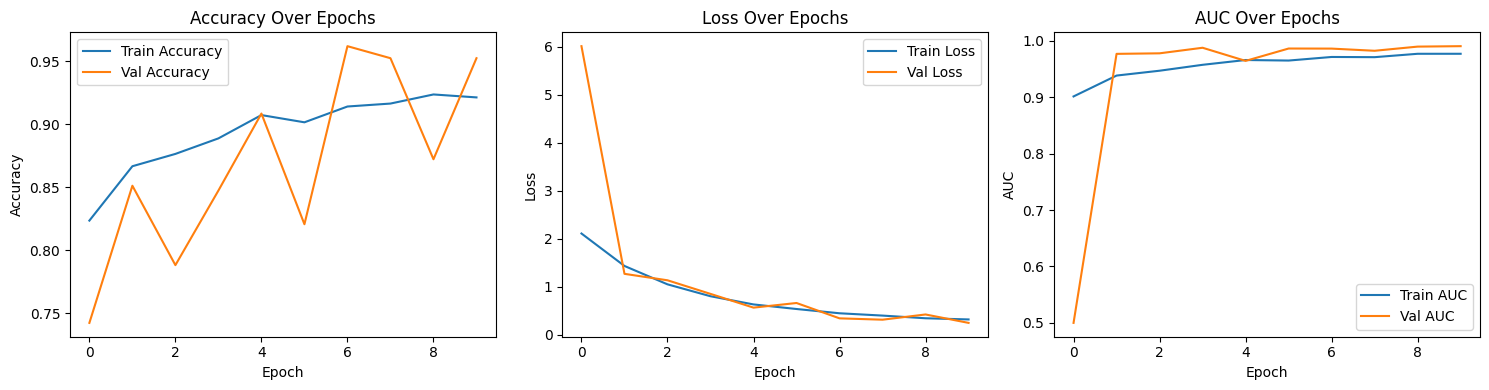

In [ ]:
# Plot training curves (loss, accuracy, and AUC)
if baseline_tuned_history is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    visualization.plot_training_history(baseline_tuned_history)

#### 7.7 Confusion Matrix & Classification Report

Test ROC-AUC: 0.9420


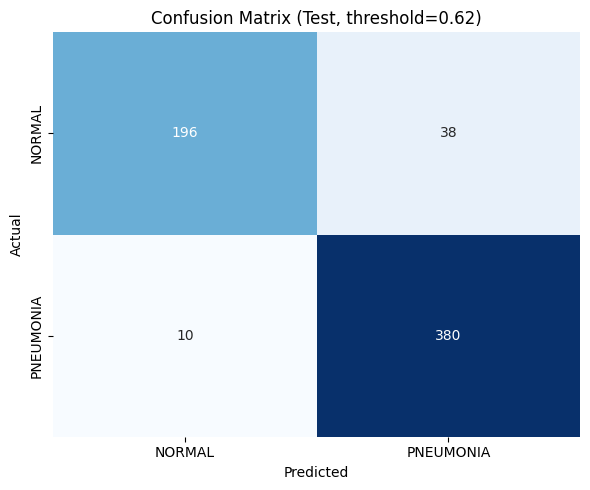

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.95      0.84      0.89       234
   PNEUMONIA       0.91      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624



In [ ]:
print(f"Test ROC-AUC: {baseline_tuned_metrics['auc']:.4f}")

visualization.plot_confusion_and_report(y_true, y_pred, best_threshold)

**Interpretation**

The CNN optimized with hyperparameter tuning showed significant gains over earlier models, reaching an overall accuracy of 0.92 (compared with 0.72 and 0.83 for the initial baselines). The model maintained near-perfect pneumonia recall at 0.97, recovering almost all of the sensitivity lost in the augmented version, while also achieving high precision at 0.91, demonstrating effective control over over-prediction of pneumonia. In practice, it missed only 10 pneumonia cases—a major improvement from the 40 missed in the augmented model—while correctly identifying an even higher proportion of healthy patients, reducing false positives to just 38 (down from 173 in the baseline and 67 in the augmented model).

This 0.92 accuracy reflects a well-calibrated balance between classes, restoring nearly the full safety net of the unaugmented model while maximizing operational efficiency by minimizing false alarms.

_Bottom Line_: The hyperparameter-tuned CNN provides an ideal compromise, addressing both the false alarm tendency of the baseline and the missed cases of the augmented model. With 92% overall accuracy and a 97% safety net, it preserves both patient safety and diagnostic reliability, making it a strong candidate for clinical use.

#### 7.8 Sample Predictions

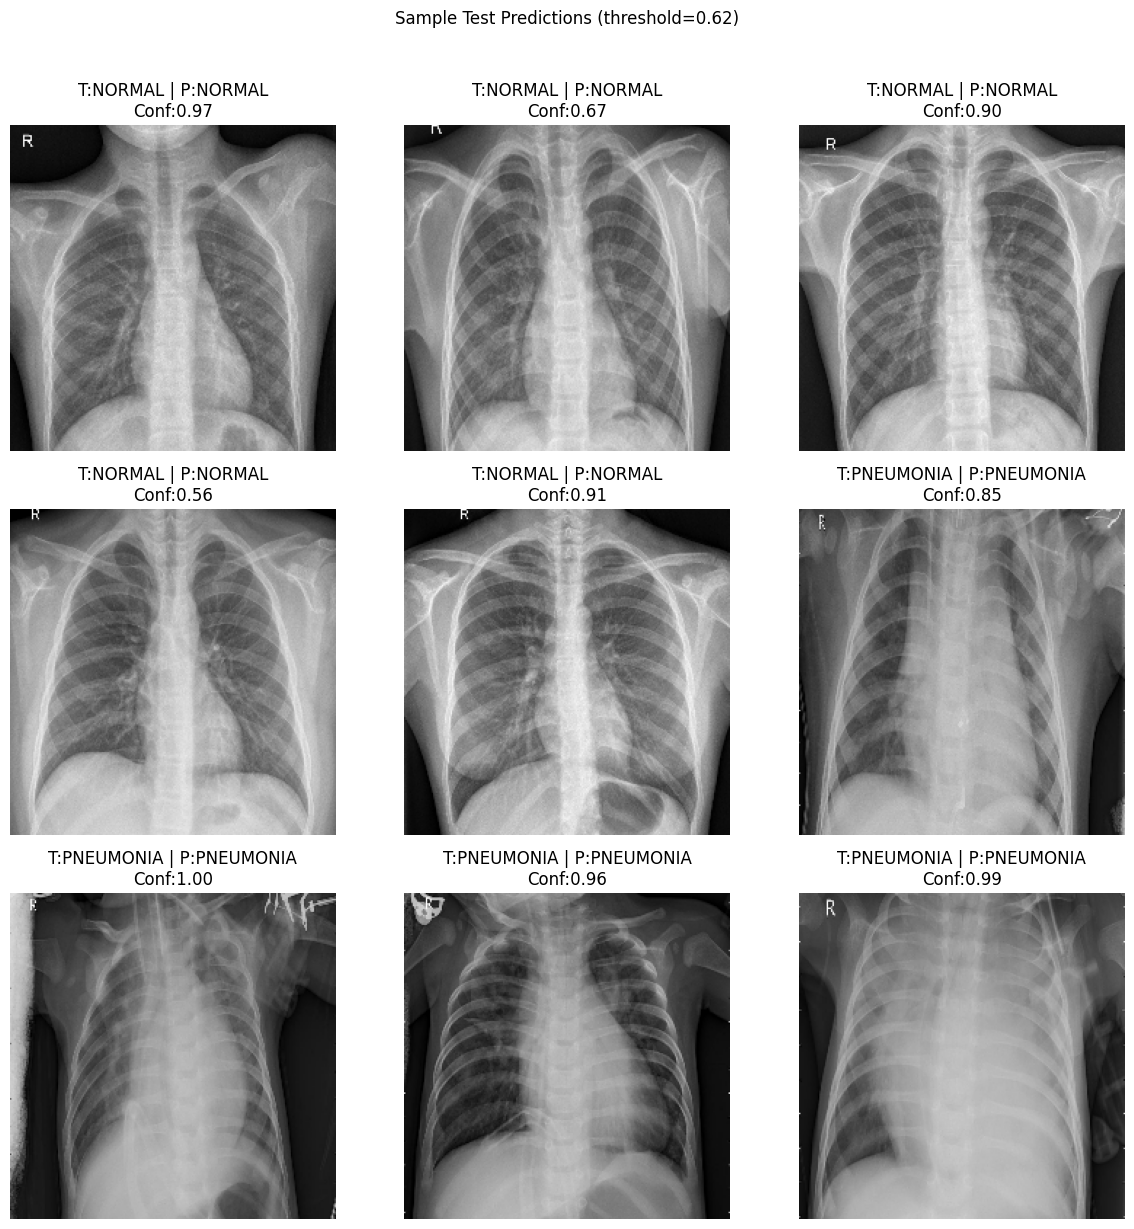

In [ ]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
visualization.plot_sample_test_predictions(test_ds, baseline_tuned_model, best_threshold)

### 8. Conclusion — CNN Model Comparison

Load saved metadata for all three models and present a side-by-side comparison.

                             Accuracy     AUC  Precision  Recall      F1  Threshold
Model                                                                              
Model A – No Augmentation      0.7228  0.8967     0.6927  1.0000  0.8185       0.79
Model B – With Augmentation    0.8285  0.8930     0.8393  0.8974  0.8674       0.33
Model C – Tuned HP             0.9231  0.9420     0.9091  0.9744  0.9406       0.62

  Best Accuracy: Model C – Tuned HP (0.9231)
  Best AUC: Model C – Tuned HP (0.9420)
  Best Precision: Model C – Tuned HP (0.9091)
  Best Recall: Model A – No Augmentation (1.0000)
  Best F1: Model C – Tuned HP (0.9406)


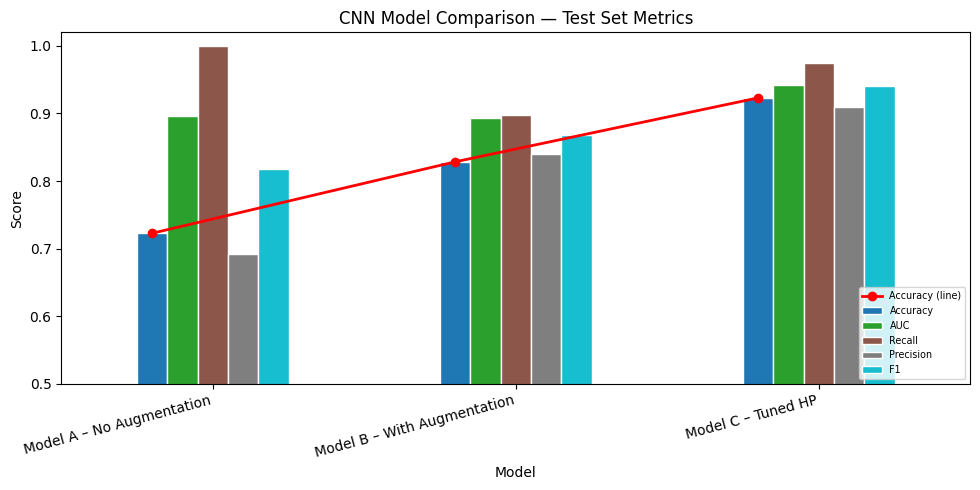

In [ ]:
# ── Final comparison: all three CNN models

models = [
    ("baseline_without_aug_cnn", "Model A – No Augmentation"),
    ("baseline_cnn", "Model B – With Augmentation"),
    ("baseline_cnn_tuned", "Model C – Tuned HP"),
]
visualization.plot_model_comparison(SAVE_DIR, models)

### Key Takeaways

- **Data augmentation** (Model B vs A) is expected to improve generalisation by exposing the model to plausible image variations and reducing overfitting to the limited training set.
- **Hyperparameter tuning** (Model C) systematically searches over architecture depth, filter counts, dropout rates, L2 strength, and learning rate to find a better configuration than the hand-tuned baseline.
- **Balanced class weighting** (via `compute_class_weights()`) is applied consistently across all three models to compensate for the PNEUMONIA-heavy class imbalance, giving more weight to the minority NORMAL class.
- **Decision threshold tuning** on the validation set (optimising PNEUMONIA F1) further improves the recall–precision trade-off beyond the default 0.5 cutoff.


![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)